# Help Desk Ticket SLA and Volume Forecasting

This capstone uses `data/raw/issues.csv` for two integrated workstreams: **(1) retrospective comparison of elapsed resolution time with project-configured SLA references by recorded priority; and (2) separate 7- and 30-day daily Ticket-volume forecasting experiments for capacity-planning research.** The 30-day forecast is a daily path, not one monthly total. The primary analysis includes `issue_type == Ticket` and creation dates on/after 2016-01-01 UTC, matching the period described in the accompanying source documentation.

**Important source caveat:** the CSV contains creation dates before 2016. Those records are profiled but excluded from the primary scope. Dates without scoped Ticket rows are treated as zero arrivals in the forecasting series under an explicit completeness assumption that has not been independently verified. The source ends in March 2023 and cannot establish current operational performance.

The configured SLA references are project assumptions: Blocker/Highest → Critical (4h), High (8h), Medium (24h), Low/Lowest → Low (24h); `unknown` is excluded. The measured duration is calendar wall-clock time between creation and recorded resolution—not a verified business-hours SLA clock. Results are retrospective, not contractual compliance or a live warning model.

**Shared retrospective result across this notebook sequence:** among 16,735 eligible completed Tickets, 3,333 (19.9%) met the configured reference. By mapped priority: Critical 524/2,124 (24.7%); High 576/3,146 (18.3%); Medium 2,161/11,161 (19.4%); Low 72/304 (23.7%). Eligibility requires exact Ticket type, documented 2016+ scope, `Done`, known mapped priority, and valid nonnegative elapsed duration. Notebook 02 shows the detailed comparison; these same counts and caveats are the project-wide retrospective baseline.


# 04 | Forecast explainability and model interpretation

The validation-selected forecast may be a statistical model rather than a tree model. Interpret the method actually selected first. As a challenger-model explanation, SHAP values, partial dependence (PDP), and a single LIME local explanation are all computed for the same one-day-ahead XGBoost model, fitted only on pre-validation history and evaluated on validation dates; no final-test outcomes inform any of these three explanations. A separate, bounded hyperparameter sensitivity check closes this notebook, asking whether the fixed XGBoost configuration used throughout this project is a robust choice or a fragile one.

In [1]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display
from src.issues_capstone import run_explainability
result = run_explainability()
print(result['interpretation'])
print('Validation-selected model:', result['validation_selected_model'])
display(result['validation_metrics'])
display(result['xgboost_importance'])
display(result['xgboost_shap'])
display(result['xgboost_pdp'])
display(result['xgboost_lime'])


XGBoost importance describes split utility within validation-fitted models, not causal ticket drivers. If seasonal naive wins, its forecast is directly traceable to the prior week's same weekday. PDP shows the average marginal effect of each top feature across the validation period; LIME shows a single local explanation for one representative validation-day forecast. All three (SHAP, PDP, LIME) explain the XGBoost challenger only, not the model actually selected for production if it differs.
Validation-selected model: ETS (weekly additive)


,split,model,forecast_window_days,forecast_days,forecast_origins,MAE,RMSE,WAPE,sMAPE,signed_bias_actual_minus_forecast,validation_abs_error_p90,coverage_90_interval,interpretation
8,validation,Seasonal naive (same weekday last week),30,359,48,5.411806,7.803089,0.395704,0.607528,0.415972,13.000000,NaN,historical backtest; transfer to current opera...
9,validation,ETS (weekly additive),30,359,48,4.393815,6.088672,0.321270,0.534821,0.777126,9.125416,NaN,historical backtest; transfer to current opera...
10,validation,XGBoost autoregression (28-day lags),30,359,48,4.684999,6.712644,0.342561,0.565102,2.307906,10.572962,NaN,historical backtest; transfer to current opera...
11,validation,Ridge (MI-selected features + PCA),30,359,48,4.778375,6.856468,0.349389,0.552272,2.625859,10.473874,NaN,historical backtest; transfer to current opera...


,forecast_window_days,feature,mean_validation_importance,validation_origins
34,30,lag_21,0.214278,48
35,30,lag_28,0.201160,48
36,30,lag_14,0.079785,48
37,30,mean_28,0.059323,48
38,30,lag_7,0.050340,48
39,30,weekday_sin,0.034871,48
40,30,mean_7,0.031088,48
41,30,lag_12,0.028621,48
42,30,weekday_cos,0.023161,48
43,30,lag_1,0.017104,48


,feature,mean_absolute_shap_value
27,lag_28,1.686717
20,lag_21,1.489818
13,lag_14,0.997245
29,mean_28,0.759788
0,lag_1,0.684291
28,mean_7,0.681279
6,lag_7,0.569625
31,weekday_cos,0.436754
33,year_cos,0.401599
5,lag_6,0.297889


,feature,grid_value,avg_predicted_tickets
0,lag_28,0.0,9.958529
1,lag_28,1.0,9.958529
2,lag_28,2.0,9.622858
3,lag_28,3.0,9.622858
4,lag_28,4.0,10.924450
...,...,...,...
110,lag_14,38.0,13.325665
111,lag_14,41.0,13.325665
112,lag_14,43.0,13.325665
113,lag_14,47.0,13.325665


,explained_date,predicted_tickets,feature_condition,local_weight
0,2021-09-13,17.885334,lag_1 > 13.00,1.451568
1,2021-09-13,17.885334,lag_28 > 13.00,1.288647
2,2021-09-13,17.885334,lag_21 > 13.00,1.277840
3,2021-09-13,17.885334,lag_14 > 13.00,1.018637
4,2021-09-13,17.885334,lag_9 <= 2.00,0.836995
5,2021-09-13,17.885334,mean_7 > 9.86,0.816640
6,2021-09-13,17.885334,weekday_cos > 0.62,0.785599
7,2021-09-13,17.885334,lag_7 > 13.00,0.552449
8,2021-09-13,17.885334,lag_12 > 13.00,0.488000
9,2021-09-13,17.885334,mean_28 > 9.57,0.417496


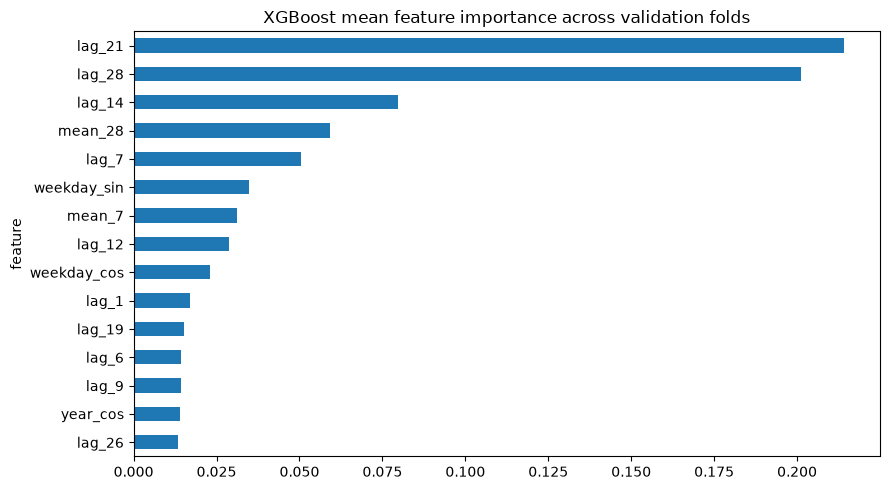

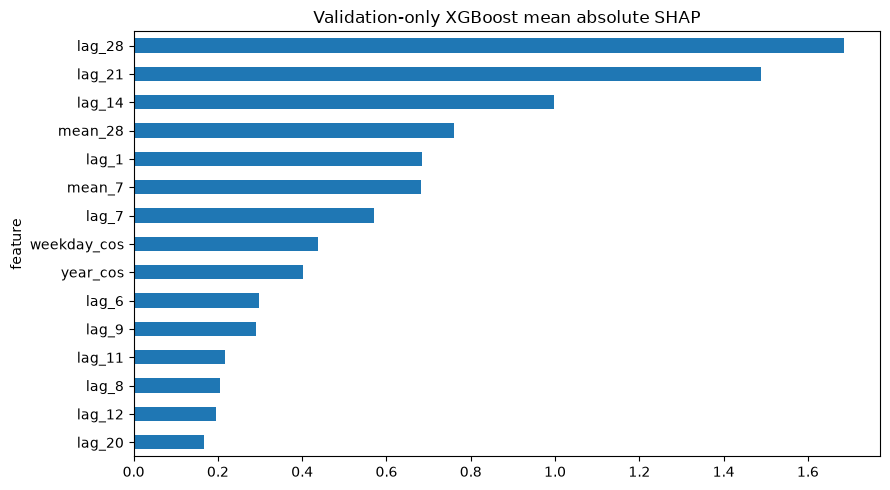

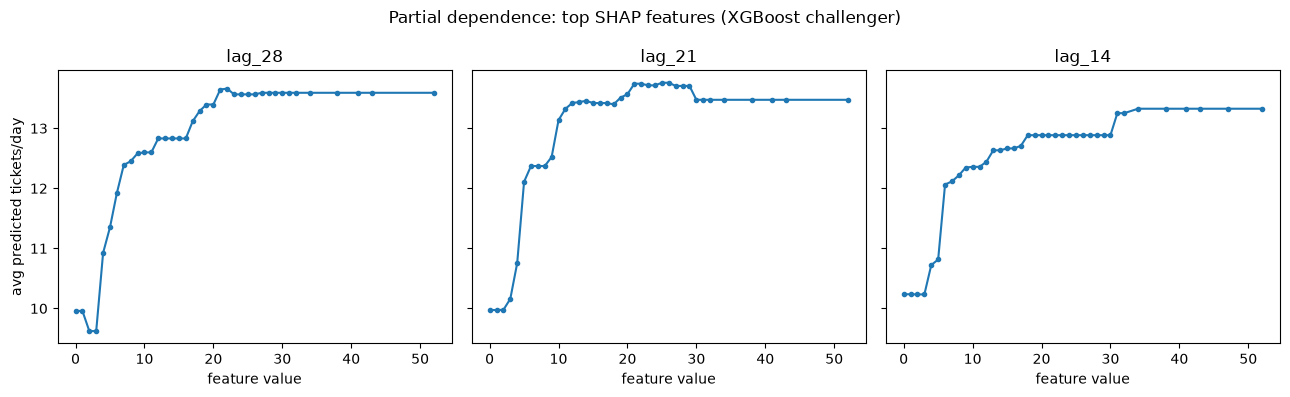

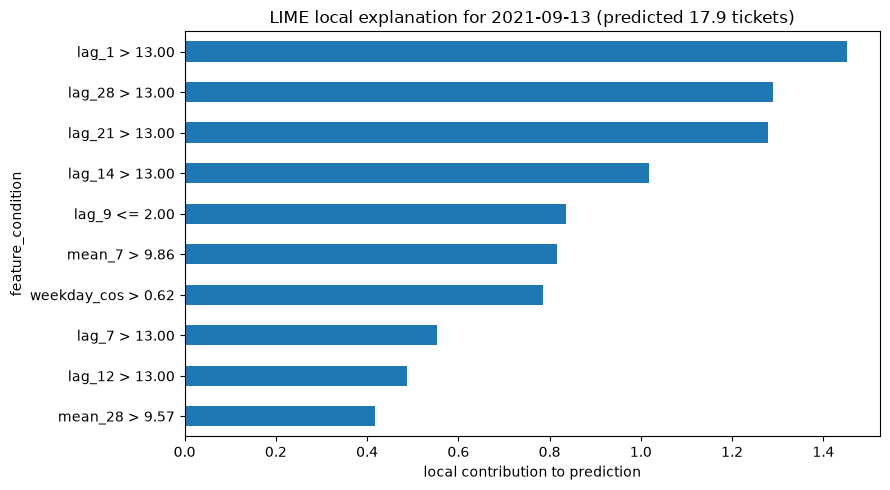

In [2]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import matplotlib.pyplot as plt
importance = result["xgboost_importance"].sort_values("mean_validation_importance")
if not importance.empty:
    importance.plot.barh(x="feature", y="mean_validation_importance", figsize=(9, 5), legend=False,
                         title="XGBoost mean feature importance across validation folds")
    plt.tight_layout()
    plt.show()
shap_summary = result["xgboost_shap"].sort_values("mean_absolute_shap_value")
shap_summary.plot.barh(x="feature", y="mean_absolute_shap_value", figsize=(9, 5), legend=False,
                       title="Validation-only XGBoost mean absolute SHAP")
plt.tight_layout()
plt.show()

pdp = result["xgboost_pdp"]
fig, axes = plt.subplots(1, pdp["feature"].nunique(), figsize=(13, 4), sharey=True)
for ax, (feature, group) in zip(axes, pdp.groupby("feature", sort=False)):
    ax.plot(group["grid_value"], group["avg_predicted_tickets"], marker=".")
    ax.set_title(feature)
    ax.set_xlabel("feature value")
axes[0].set_ylabel("avg predicted tickets/day")
fig.suptitle("Partial dependence: top SHAP features (XGBoost challenger)")
plt.tight_layout()
plt.show()

lime_summary = result["xgboost_lime"]
lime_summary.set_index("feature_condition")["local_weight"].sort_values().plot.barh(
    figsize=(9, 5),
    title=f"LIME local explanation for {lime_summary['explained_date'].iloc[0]}"
    f" (predicted {lime_summary['predicted_tickets'].iloc[0]:.1f} tickets)",
)
plt.xlabel("local contribution to prediction")
plt.tight_layout()
plt.show()


## Explainability summary

**Validation selects XGBoost for 7 days and weekly additive ETS for the primary 30-day horizon.** ETS is interpreted through its estimated level, trend and weekly seasonal pattern; the XGBoost explanations below do not explain the persisted ETS artifact.

XGBoost is the 30-day challenger and the validation-selected 7-day model family. The SHAP/PDP/LIME charts explain a separate **one-day-ahead** XGBoost fit trained before the validation year, not every fitted model at every rolling origin. The largest mean-absolute SHAP contributions are lags 28, 21 and 14. Mean absolute SHAP describes how much a feature tends to move predictions, not whether it raises or lowers a particular forecast. PDP averages feature-response behavior across validation observations; LIME explains one representative validation day. Correlated lags can share attribution. These are predictive associations, not causal demand drivers, and none of these charts explains the ETS artifact or current operational demand.

## Explainability limits

For seasonal naive, the forecast is traceable to the previous week's same weekday. ETS represents level, trend and weekly seasonality. SHAP, PDP and LIME explain the same pre-validation XGBoost fit; correlated lags can share contribution, and these methods are not causal. PDP's averaging can mask feature interactions; a single LIME case describes only one prediction. The explanations are not directly interchangeable with rolling-origin XGBoost refits and do not explain the primary 30-day ETS forecast.

## Hyperparameter sensitivity check

Every XGBoost fit in this project (the challenger above and the model-comparison run in Notebook 03) uses one fixed configuration from `configs/project_config.yaml`, with no grid search or automated tuning. `run_hyperparameter_sensitivity()` asks a narrower, cheaper question instead: starting from that configured baseline, how much does one-day-ahead validation MAE move if `max_depth`, `learning_rate`, `n_estimators` or `reg_lambda` are individually perturbed? Each variant is fit once on the same pre-validation history and scored on the same validation days used elsewhere in this notebook, so this reuses the existing leakage-safe split rather than touching the final test period. It is a sensitivity/robustness check on the configured settings, not a replacement for the multi-horizon rolling-origin backtest that actually selects the reported model in Notebook 03.

Single-step one-day-ahead validation-period refits used to bound hyperparameter sensitivity cheaply; the configured baseline is not always the single best variant here, but this one-step proxy is a sensitivity check, not the model-selection metric (that remains the multi-horizon rolling-origin validation MAE in volume_forecast_rolling_metrics.csv). A large swing across variants would indicate a fragile, poorly-chosen configuration; a small swing indicates the forecast is robust to reasonable hyperparameter choices.
Baseline params: {'objective': 'reg:squarederror', 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.04, 'min_child_weight': 3, 'subsample': 0.9, 'colsample_bytree': 0.9, 'reg_lambda': 5.0, 'random_state': 42, 'n_jobs': 1}
Largest swing vs baseline: 4.4%


,variant,changed_params,validation_mae,validation_rmse,validation_days_scored,mae_change_vs_baseline_pct
0,configured (baseline),(none),4.142811,6.036094,365,0.000000
2,deeper_trees,"{""max_depth"": 5}",4.185528,6.045038,365,1.031105
7,no_regularization,"{""reg_lambda"": 0.0}",4.214557,6.103658,365,1.731807
1,shallower_trees,"{""max_depth"": 2}",4.233434,6.134601,365,2.187479
3,lower_learning_rate,"{""learning_rate"": 0.02}",4.244284,6.182495,365,2.449359
5,fewer_trees,"{""n_estimators"": 100}",4.246365,6.169088,365,2.499607
6,more_trees,"{""n_estimators"": 600}",4.272275,6.171709,365,3.125010
4,higher_learning_rate,"{""learning_rate"": 0.12}",4.323824,6.235335,365,4.369328


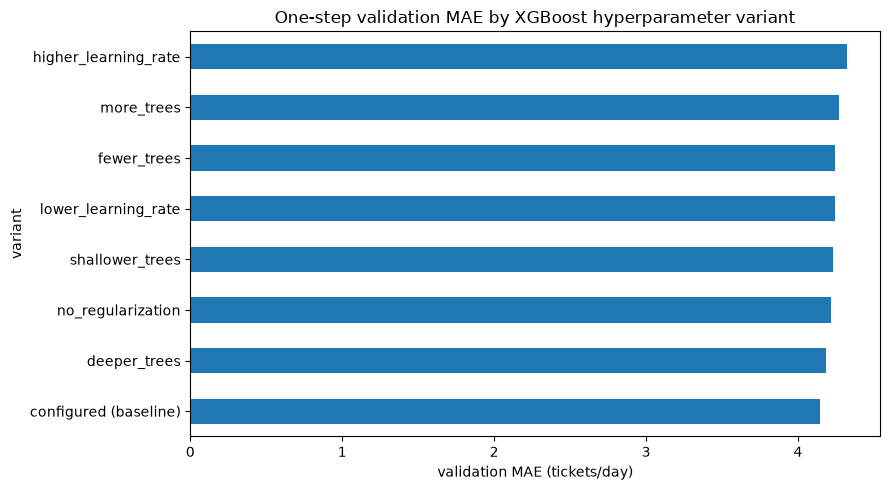

In [3]:
from pathlib import Path
import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from IPython.display import display
import matplotlib.pyplot as plt
from src.issues_capstone import run_hyperparameter_sensitivity
sensitivity = run_hyperparameter_sensitivity()
print(sensitivity['interpretation'])
print('Baseline params:', sensitivity['baseline_params'])
print(f"Largest swing vs baseline: {sensitivity['max_mae_swing_vs_baseline_pct']:.1f}%")
display(sensitivity['sensitivity_table'])
sensitivity['sensitivity_table'].set_index('variant')['validation_mae'].sort_values().plot.barh(
    figsize=(9, 5), title='One-step validation MAE by XGBoost hyperparameter variant'
)
plt.xlabel('validation MAE (tickets/day)')
plt.tight_layout()
plt.show()


## Reading the sensitivity results

Across eight variants (baseline plus seven perturbations of tree depth, learning rate, tree count and regularization), one-step validation MAE ranges from about 4.14 to 4.32 tickets/day, a roughly 4% spread; the configured baseline (now `n_estimators: 200`, adopted after the tuning search below) is the single best-performing variant in this grid. The most sensitive setting is learning rate, where tripling it raises error the most; deeper trees, dropped regularization, shallower trees, a lower learning rate, fewer trees and more trees all shift error only slightly. This indicates the configured XGBoost setting is a reasonable, non-fragile choice for this series — not a value the project happened to get lucky with — though a bounded one-step proxy alone does not prove it is the single best possible configuration under the real multi-horizon rolling-origin criterion; the tuning search below closes that remaining gap directly.

## Closing the gap: a bounded, two-stage hyperparameter search

The sensitivity check above answers a narrower question than a real tuning process: it perturbs one setting at a time around the configured baseline. It does not search combinations of settings, and it never re-validates a candidate against the actual multi-horizon rolling-origin backtest that selects the reported model in Notebook 03. A full grid search across every origin and both horizons was timed at roughly 480 seconds per full pipeline run (Notebook 03's `run_volume_forecast()`), which makes scoring dozens of hyperparameter combinations through the complete rolling-origin loop computationally prohibitive for this project.

`run_hyperparameter_tuning()` resolves this with a two-stage design instead of skipping tuning altogether:

1. **Stage 1 (cheap search).** A grid of up to 27 combinations of `max_depth`, `learning_rate` and `n_estimators` around the configured baseline is scored with the same one-step-ahead validation refit used in the sensitivity check above. This is fast (seconds per combination) but is only a proxy for the real, multi-horizon rolling-origin selection criterion.
2. **Stage 2 (honest validation).** Only if Stage 1's best combination differs from the currently configured baseline, that single candidate is re-fit through the real rolling-origin backtest at both the 7- and 30-day horizons, restricted to validation-period origins only (the final test split is never touched by this search). The baseline side of the comparison is reused from `volume_forecast_rolling_metrics.csv` rather than recomputed, so this stays inexpensive.

If the candidate beats the baseline at both horizons on this honest criterion, adopting it means updating `configs/project_config.yaml` and re-running the full pipeline (`run_volume_forecast`, `run_explainability`, model persistence and MLflow logging) so every reported number in this project reflects one consistent configuration — never a silent, partial edit.

In [4]:
from src.issues_capstone import run_hyperparameter_tuning
tuning = run_hyperparameter_tuning()
print('Decision:', tuning['decision'])
print()
print(tuning['recommendation'])
print()
print('Stage 1 top candidates (lowest one-step validation MAE):')
display(tuning['search_results'].head(10))
if tuning['rolling_validation_comparison'] is not None:
    print()
    print('Stage 2 rolling-origin validation (baseline vs. Stage-1 winner):')
    display(tuning['rolling_validation_comparison'])


Decision: keep_baseline

Stage-1 search confirmed the currently configured hyperparameters are already the lowest one-step validation-MAE combination in the searched grid; no Stage-2 rolling-origin re-validation was necessary. No change to configs/project_config.yaml is recommended.

Stage 1 top candidates (lowest one-step validation MAE):


,max_depth,learning_rate,n_estimators,is_configured_baseline,one_step_validation_mae
0,3,0.04,200,True,4.142811
1,5,0.08,100,False,4.163420
2,3,0.02,400,False,4.168842
3,5,0.02,400,False,4.169789
4,5,0.04,100,False,4.171634
5,5,0.04,200,False,4.185528
6,5,0.02,200,False,4.187782
7,3,0.04,400,False,4.204496
8,3,0.08,100,False,4.218038
9,2,0.04,400,False,4.227300



Stage 2 rolling-origin validation (baseline vs. Stage-1 winner):


,forecast_window_days,baseline_validation_mae,candidate_validation_mae,candidate_wins
0,7,4.181157,4.181157,False
1,30,4.684999,4.684999,False


## Reading the tuning outcome

The corrected run reports `keep_baseline`: the one-step validation search selects the existing `n_estimators: 200` configuration, so no distinct candidate requires another rolling-origin evaluation. Its corrected rolling-validation baseline MAEs are 4.181 at 7 days and 4.685 at 30 days; equal candidate/baseline values do not represent a new improvement. Earlier claims comparing the 100-tree and 200-tree settings used the pre-correction calendar and are superseded, not evidence of a verified current improvement. The search remains bounded to three hyperparameters and up to 27 combinations. The code rejects an old calendar-policy baseline before comparing a different candidate.

## In summary

The primary 30-day ETS model is interpreted through its trend and weekly pattern. SHAP, PDP and LIME describe a separate XGBoost explanation model; XGBoost is also the validation-selected 7-day family. Sensitivity checks and a bounded parameter search examine robustness without consulting the final test for selection. The corrected search retains the existing configuration; it does not establish a newly adopted improvement or a globally optimal model.